In [1]:
import os
from math import pi
import cmath

import numpy as np
import pandas as pd

from IPython.display import clear_output
clear_output(wait=True)
import netket as nk
import jax
from netket.operator.spin import sigmax,sigmaz
from jax import numpy as jnp
import orbax.checkpoint as ocp
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import flax
from flax.training import checkpoints
import optax
from flax import linen as nn
from functools import partial
from netket import jax as nkjax
from modified_nk_ARNN import *
import optax
from flax import linen as nn

## spin-1 model
$$H = \sum_i \cos(\theta)\mathbf{S}_i\mathbf{S}_{i+1}  + \sin(\theta)(\mathbf{S}_i\mathbf{S}_{i+1})^2$$

In [2]:
path = "/home/ywatanabe/Dropbox/RESEARCH/MachineLearning/pcVAE_experiment"

## Dataset
Read samples generated from the calculated MPS through DMRG from file.
訓練データとテストデータの分け方

- 異なるパラメータを訓練データとテストデータに割り当てる
- 同じパラメータでサンプリングをし直して訓練データとテストデータに割り当てる(先行研究)

In [3]:
N = 50
# read samples from file
dirname = path + "/results/samples/" + "N{}_J1.0".format(N)
Nsamples = 500
thetas = list(np.arange(-pi,pi,0.6))
d = {}
for theta in thetas:
    dirname_sample = dirname + "/theta_" + "{:.3f}".format(theta)
    samples = []
    for i in range(1,Nsamples+1):
        sample = []
        filename = dirname_sample + "/samples_" + str(Nsamples) + '/' + str(i) + '.dat'
        with open(filename, 'r') as f:
            for line in f:
                sample.append(int(line.strip()))
        samples.append(sample)
    key = "{:.3f}".format(theta)
    d[key] = samples
df = pd.DataFrame([
    {'theta': float(k), 'samples': v} for k, v in d.items()
])

In [4]:
df.head()

,theta,samples
0,-3.142,"[[1, 0, 0, 1, 1, 1, 0, 0, 1, 0, -1, 1, 0, 0, 1..."
1,-2.542,"[[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, -1, -..."
2,-1.942,"[[0, 0, 0, 0, 1, -1, 1, -1, -1, 1, 1, -1, 1, -..."
3,-1.342,"[[1, -1, -1, 1, -1, 1, 1, -1, 1, -1, 1, -1, 0,..."
4,-0.742,"[[1, -1, 0, -1, 0, 1, 0, 0, -1, 1, 0, 0, 0, 0,..."


### Physical quantities from samplings
- $\braket{S^z_i}$
- string cor
  $$ C_{stg}(r=|j-i|) = -\Braket{S^z_i \exp(i\pi\sum_{k=i+1}^{j-1}S^z_k)S^z_j} $$
  Here, we use $i=1$, $j=i+r=1+r$

In [5]:
def Sz_fromSamples(samples):
    N = len(samples[0])
    Szs = []
    for i in range(N):
        Szs.append(float(np.array(samples)[:,i].mean()))
    return Szs

def stgcor_fromSamples(samples_list):
    i=1
    samples = np.array(samples_list)
    Nsamples, N = len(samples), len(samples[0])
    cor = np.zeros(N-1)
    cor_list = []
    for j in range(i+1,N+1): # j run 2 to N
        for s in range(Nsamples):
            cor[j-2] += -1.0*samples[s,0]*cmath.exp(1j*pi*samples[s, 1:j-1].sum())*samples[s, j-1]
        cor_list.append(float(cor[j-2]/Nsamples))
    return cor_list

def quantity_fromSample(df, samplename, quantityname, typename=None):
    quantity = [] # for different theta
    for i in range(len(df)):
        samples_i = df.iloc[i][samplename]
        if quantityname == "Szs":
            quantity.append(Sz_fromSamples(samples_i))
        if quantityname == "stgcor":
            quantity.append(stgcor_fromSamples(samples_i))   
    df[quantityname+'_'+typename] = quantity
    return df


In [6]:
# physical quantity with sampling data
quantity_fromSample(df, 'samples', "Szs", 'true')
quantity_fromSample(df, 'samples', "stgcor", "true")
df.head()

/tmp/ipykernel_14846/2115445960.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  cor[j-2] += -1.0*samples[s,0]*cmath.exp(1j*pi*samples[s, 1:j-1].sum())*samples[s, j-1]


,theta,samples,Szs_true,stgcor_true
0,-3.142,"[[1, 0, 0, 1, 1, 1, 0, 0, 1, 0, -1, 1, 0, 0, 1...","[0.334, 0.26, 0.33, 0.344, 0.378, 0.334, 0.362...","[-0.082, 0.028, 0.022, -0.024, -0.012, 0.0, -0..."
1,-2.542,"[[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, -1, -...","[0.364, 0.434, 0.382, 0.418, 0.36, 0.38, 0.398...","[-0.13, 0.06, 0.0, -0.014, -0.02, 0.014, -0.06..."
2,-1.942,"[[0, 0, 0, 0, 1, -1, 1, -1, -1, 1, 1, -1, 1, -...","[-0.05, 0.032, 0.046, -0.024, -0.01, 0.012, 0....","[0.584, 0.084, 0.096, 0.008, 0.04, -0.014, 0.0..."
3,-1.342,"[[1, -1, -1, 1, -1, 1, 1, -1, 1, -1, 1, -1, 0,...","[0.092, -0.092, 0.048, -0.072, -0.004, 0.032, ...","[0.602, 0.126, 0.16, 0.04, 0.058, 0.026, 0.042..."
4,-0.742,"[[1, -1, 0, -1, 0, 1, 0, 0, -1, 1, 0, 0, 0, 0,...","[-0.012, -0.028, 0.082, -0.072, -0.004, 0.05, ...","[0.612, 0.248, 0.246, 0.116, 0.124, 0.114, 0.1..."


### Train/Test split
訓練用とテスト用のデータセットを全データセットからそれぞれ抽出する。パラメータθが被らないようにする。

In [7]:
def train_test_split(df, rate=0.8, random_state=None):
    df_random = df.sample(frac=1, random_state=random_state)

    N_train = int(len(df)*rate)
    df_train = df_random[0:N_train]
    df_test  = df_random[N_train:]
    return df_train, df_test


def phase_data(df, phase_name):
    """
    return all the data which is in 'phase_name'
        - phase_name: 'haldane', 'trimer', 'ferro', 'dimer'
    """
    if phase_name == 'haldane':
        return df[(((df['theta'] >= 0.0) & (df['theta'] < pi/4)) | ((df['theta'] > -pi/4) & (df['theta'] < 0.0)))]
    elif phase_name == 'trimer':
        return df[(df['theta'] > pi/4) & (df['theta'] < pi/2)]
    elif phase_name == 'ferro':
        return df[ ((df['theta']>pi/2) & (df['theta']<=pi)) | ((df['theta']>-pi) & (df['theta']<-3*pi/4)) ]
    elif phase_name == 'dimer':
        return df[(df['theta']>-3*pi/4) & (df['theta']<-pi/4)]
    else:
        ptintln("'phase_name': {phase_name} is invalid. return original DataFrame")
        return df
        
def create_dataset(df, rate=0.8, random_state=None):
    df_train, df_test = train_test_split(df, rate=rate, random_state=random_state)
    train_dataset = jnp.array(list(df_train['samples'].values))
    test_dataset  = jnp.array(list(df_test['samples'].values))

    return train_dataset, test_dataset, df_train, df_test
    

In [8]:
train_dataset, test_dataset, df_train, df_test = create_dataset(df, rate=0.8)

## $\beta$-VAEs
In the following, we create the $\beta$-VAE where the KL divergence term can be tuned with the parameter $\beta$.

- $\beta$-dVAE \
  Conventional VAE where the decoder generate the output without conditional probability
- $\beta$-cpVAE \
  cpVAE introduced in Schoulpnikoff2025. Decoder has ARNN structure which generate the sampling with conditional probability.

$\beta$-VAE optimize its parameter with the following loss function:
$$ \mathcal{L} = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]] + \beta D_{\text{KL}}(q_\theta(z|x)||p_\theta(z)) $$

### model

In [9]:
# for cpVAE
from modified_nk_ARNN import *

class EncoderCNN(nn.Module):
    """ encoder """
    latent_dim: int

    @nn.compact # to write definition of layers and calculation at once
    def __call__(self, x):
        # x shape: (batch, length)
        # reshape x to (batch, length, channels(=1))
        x = x.reshape((x.shape[0], x.shape[1], 1))

        # convs (2 Conv1D for periodic data)
        # Use 32 kenerls (size 3)
        x = nn.Conv(features=32, kernel_size=(3,), strides=(1,), padding='VALID', use_bias=True)(x)
        x = nn.relu(x)
        x = nn.Conv(features=32, kernel_size=(3,), strides=(1,), padding='VALID', use_bias=True)(x)
        x = nn.relu(x)

        # Gloval average Pooling over the spatial dimension
        # Take average along spin sites
        # x -> (batch, 1 , features)
        x = x.mean(axis=1)

        # Dense layer for 'mean' and 'variance'
        # finally reduce the numbber of neuron to the latent space dim
        # mean
        mean = nn.Dense(features=64)(x)
        mean = nn.relu(mean)
        mean = nn.Dense(features=self.latent_dim)(mean)

        # variance
        logvar = nn.Dense(features=64)(x)
        logvar = nn.relu(logvar)
        logvar = nn.Dense(features=self.latent_dim)(logvar)

        return mean, logvar

class Encoder_and_latent(nn.Module):
    latent_dim: int

    def setup(self):
        self.encoder = EncoderCNN(self.latent_dim)

    def reparameterize(self, mean, logvar, key):
        # Reparameterization trick
        std = jnp.exp(0.5 * logvar)
        #std = jnp.exp(logvar)
        eps = jax.random.normal(key, mean.shape)
        return mean + eps * std

    def __call__(self, x, key):

        mean, logvar = self.encoder(x)
        z = self.reparameterize(mean, logvar, key)

        return mean, logvar, z


### loss function

For the cpVAE, the ARNN generate the spin configuration with the conditional probability.
In the paper, the loss function for cpVAE is formalized as eq.(7), where the reconstruction error is calculated as
$$ \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z))] =  \mathbb{E}_{q_\phi(z|x)}\sum_i (x_i-1)\log p_i + (x_i+1)\log(1-p_i) $$
where the probability mass function $f(p_i, x_i)$ for the two possible outcome $x_i\in\{+1,-1\}$ with possibility $p_i$ is given by the Bernouilli distributiuon.
The whole spin configuration generated from decoder of cpVAE is written as the product of the conditional probabilities of each spin,
$$ p(x) = \prod_{i=1}^N p(x_i|x_0, x_2, \cdots, x_{i-1}) $$

The number of categories can be more than $K=3$. The generalized mass function reads,
$$ \prod_{k=1}^K (p(x_{i,k}))^{x_{i,k}} $$
and the reconstruction error can be written as
$$ \sum_{i=1}^N \sum_{k=1}^K x_{i,k}\log p(x_{i,k}) $$
For the calculation, it is convinient to use the one-hot encoding, where for any lattice site $i$, only one $x_{i,k}$ is $1$ and 0 otherwise. Namely, $x_{i,k}=1, x_{i,j\neq k}=0$. With one-hot encoding, the reconstruction error can be written as
$$ \sum_{i=1}^N \sum_{k=1}^K \log p(x_{i,k}=1) $$

EXAMPLE:

Consider $N=4$ system and the spin configuration is $s = [-1,1,-1,1]$. For encoding, one needs to map the spin configuration in to positive indices, such as $-1\rightarrow 0$ and $+1\rightarrow 1$. The mapped configuration is $s_{\text{map}} = [0,1,0,1]$. Using one_hot() function, it will return $N\times K$ array, which contains

one_hot($s_{\text{map}}$, $K=2$)
$$\rightarrow [[x_{i=1,k=1}, x_{i=1,k=2}], [x_{i=2,k=1}, x_{i=2,k=2}], [x_{i=3,k=1}, x_{i=3,k=2}], [x_{i=4,k=1}, x_{i=4,k=2}]] = [[1,0],[0.1],[1,0],[0,1]]$$

Obtraining the same array structure of logrithmic probability, such as,

$\log p$
$$\rightarrow [[\log p(x_{i=1,k=1}), \log p(x_{i=1,k=2})], [\log p(x_{i=2,k=1}), \log p(x_{i=2,k=2})], [\log p(x_{i=3,k=1}), \log p(x_{i=3,k=2})], [\log p(x_{i=4,k=1}), \log p(x_{i=4,k=2})]]$$

we can calculate the reconstruction error simply one_hot($s_{\text{map}}$, $K=2$)*$\log p$

In [10]:
# for cpVAE
@jax.jit
def RC_loss(params, batch, key):
    params_encoder, params_decoder = params

    key = jax.random.split(key)[0]
    mean, logvar, z  = enc_lat.apply({'params': params_encoder}, batch, key)

    # Reconstruction loss
    x = batch
    inputs = jnp.concatenate((z, x), axis=1)
    eps = 1e-10
    # log conditional probability log(p(x_i)): B*N*K
    p_i = decoder.apply(params_decoder, inputs, method=decoder.conditionals)[:,latent_dim:,:]
    log_p_i = jnp.log(p_i+eps)
    
    # reconstruction error for categorical distribution with one-hot encoding
    # nn.one_hot(targets, num_classes): B*N*K
    num_classes = jnp.shape(log_p_i)[-1] # = 3 for spin-1
    targets = batch  # B*N
    # map (-1,0,1) --> (0,1,2)
    targets = jnp.astype(targets+1, int) 
    # cross entropy
    log_p = nn.one_hot(targets, num_classes)*(log_p_i)
    CE = -1.0*log_p
    #recon_loss = -jnp.mean(log_p) #double sum over samples in batch and spatial dimension

    #return recon_loss/jnp.shape(x)[0]
    return jnp.mean(CE)
    
@jax.jit
def KL_loss(params, batch, key):
    params_encoder, params_decoder = params
    key = jax.random.split(key)[0]
    
    mean, logvar, z = enc_lat.apply({'params': params_encoder}, batch, key)
    kl_loss = -jnp.sum(1 + logvar - jnp.square(mean) - jnp.exp(logvar))
    loss = kl_loss
    x = batch
    return loss/jnp.shape(x)[0]

@jax.jit
def compute_loss(params, batch, beta, key):
    recon_loss = RC_loss(params, batch, key)
    kl_loss = KL_loss(params, batch, key)
    
    loss = recon_loss + beta*kl_loss
    
    return loss/jnp.shape(batch)[0]

val_grad_fn = jax.jit(jax.value_and_grad(compute_loss))

### batch size

In [11]:
def batch_data(dataset, batch_size): # 'dataset' shape: (# of params)*(# of samples), N
  num_samples = dataset.shape[0] # (# of params)*(# of samples)
  num_batches = num_samples // batch_size
  batches = []
  for i in range(num_batches):
    batch = dataset[i * batch_size : (i + 1) * batch_size]
    batches.append(batch)
  return batches

batch_size = 50
batches = batch_data(train_dataset.reshape(-1,N), batch_size=batch_size)
batches = jax.device_put(batches) # transfer to GPU

### Training for $\beta$-cpVAE

In [12]:
dirname_res = path + "/results_VAE/beta_cpVAE" + "/N{}_J1.0".format(N)
os.makedirs(dirname_res, exist_ok=True)

### INITIALIZATION ###

# keys
input_init = batches[0]
rng = jax.random.PRNGKey(1234)
key_init = jax.random.PRNGKey(124)
key = jax.random.PRNGKey(12)

# encoder
latent_dim =  5
enc_lat = Encoder_and_latent(latent_dim=latent_dim)
params_encoder = enc_lat.init(rng, input_init, key_init)['params']

# decoder
features = 2*N
layers = 3
hi = nk.hilbert.Spin(s=1, N=N)
decoder = ARNNDense(hilbert=hi, layers=layers, features=features)
params_decoder = decoder.init(jax.random.PRNGKey(0), jnp.ones((1, N+latent_dim)))

params = (params_encoder, params_decoder)

#Optimizer
lr = 0.001
opt = optax.adabelief(learning_rate=lr)
opt_state = opt.init(params)

# epochs
num_epochs = 20
beta = 1.0

### TRAINING ###
history_loss = []
history_loss_KL = []
history_loss_RC = []
history_logvar = []

for i in range(num_epochs):
    for j, batch in enumerate(batches):
        key = jax.random.split(key)[0]
        
        val, grad = val_grad_fn(params, batch, beta, key)
        updates, opt_state = opt.update(grad, opt_state, params)
        params = optax.apply_updates(params, updates)
        
        if j%10==0:
            history_loss.append(val.tolist())
            KL = beta*KL_loss(params, batch, key).tolist()
            history_loss_KL.append(KL)
            RC = RC_loss(params, batch, key).tolist()
            history_loss_RC.append(RC)
        
            mean, logvar, z = enc_lat.apply({'params': params[0]}, batch, key)
            history_logvar.append(logvar)
        
        
        if i%1==0 and j==0:
            print("step: {}, loss: {}, bKL: {}, RC: {}".format(i,val,KL,RC))
            print("logvar: {}".format(jnp.mean(logvar, axis=0)))

history_logvar = jnp.array(history_logvar)

# output to file
data = {'params': params, 'history_loss': history_loss, 'history_loss_KL': history_loss_KL, 'history_loss_RC': history_loss_RC, 'beta':beta, 'history_logvar': history_logvar}
with open('{}/model_beta-cpVAE.pkl'.format(dirname_res), 'wb') as f:
    pickle.dump(data, f)

step: 0, loss: 0.0190063274331219, bKL: 0.28843024373054504, RC: 0.8333897478058545
logvar: [ 0.11859354 -0.00619372  0.25224087  0.13171645  0.05141564]
step: 1, loss: 0.023743774955568828, bKL: 0.006447406951338053, RC: 0.9255520437999294
logvar: [-0.07991187 -0.01143022 -0.03321171  0.01208028 -0.02912358]
step: 2, loss: 0.01433419703283747, bKL: 0.0017056488431990147, RC: 0.5578165463128433
logvar: [-0.01410803 -0.01545392 -0.00867985  0.00256065 -0.02320354]
step: 3, loss: 0.01133143804082915, bKL: 0.0005041300901211798, RC: 0.45607253468684406
logvar: [-0.00202652 -0.00469317 -0.00838966  0.00348681  0.00355809]
step: 4, loss: 0.010670296020718919, bKL: 0.00046772477799095213, RC: 0.44178181843185954
logvar: [ 0.00228386 -0.0008144  -0.00580608  0.00463131  0.00669847]
step: 5, loss: 0.01010797841688985, bKL: 0.0005184888723306358, RC: 0.4172242348873332
logvar: [ 0.00442291  0.00348303 -0.00843159  0.00463901  0.00901099]
step: 6, loss: 0.009393729617406709, bKL: 0.0004259610141

## Analyze results
1. Loss function
2. Reconstruction error when 'test' dataset is feeded to VAE
3. Compare quantities calculated with the generated samplings and the true samplings
4. Visualize latent space (meam values)

In [13]:
with open('{}/model_beta-cpVAE.pkl'.format(dirname_res), 'rb') as f:
    data = pickle.load(f)

#### loss function plot

In [14]:
def plot_training(history_loss_RC, history_loss_KL, history_logvar, dirname_res):
    # loss
    plt.semilogy(history_loss_RC,color=sns.color_palette('Paired')[1], label="RC")
    plt.semilogy(jnp.array(history_loss_KL),color=sns.color_palette('Paired')[9], label=r'$D_{KL}$')
    plt.xlabel('epochs')
    plt.ylabel(r'$\beta$VAE loss')
    plt.title(r'$\beta$='+str(beta))
    plt.legend()
    plt.savefig("{}/loss.png".format(dirname_res))
    plt.show()
    
    
    # variance
    plt.plot(jnp.mean(history_logvar, axis=1), label='$\log(\sigma)$')
    plt.xlabel('epochs')
    plt.ylabel(r'$\log(\sigma)$')
    plt.title(r'$\beta$='+str(beta))
    plt.legend()
    plt.savefig("{}/logvar.png".format(dirname_res))
    plt.show()

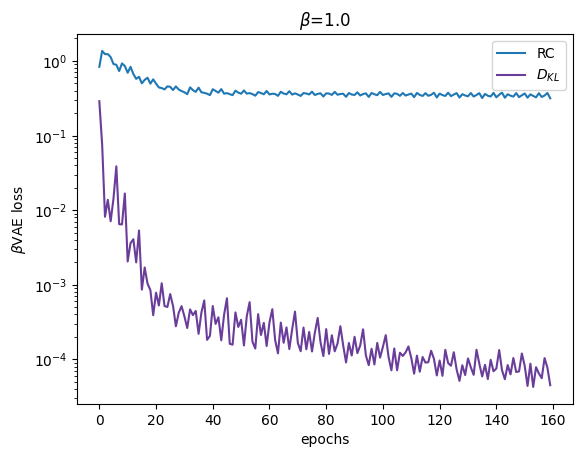

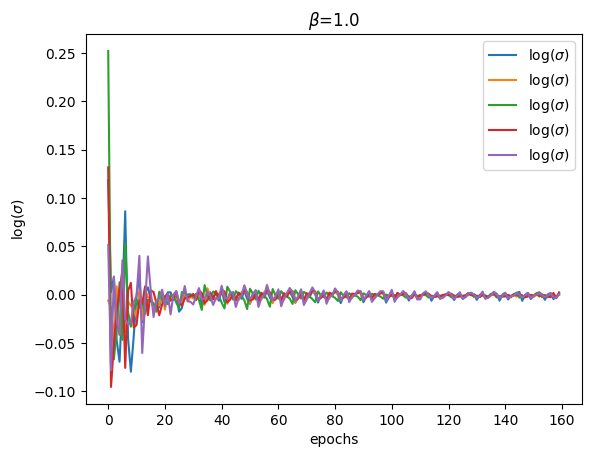

In [15]:
plot_training(data['history_loss_RC'], data['history_loss_KL'], data['history_logvar'], dirname_res)

#### reconstruction error with test dataset

In [16]:
@partial(jax.jit, static_argnums=(0,))
def get_sample(model, params, latent_var, key):
    r"""
    get sample from NN in $s \in {-1, 0, 1}$, just one sample for now
    params: Parameters of classical model
    model: Netket ARNN model
    latent_var: latent variable

    Return: Samples, samples[0]='# of samples', samples[1]='# of lattice site'
    """
    size_batch = jnp.shape(latent_var)[0]
    latent_dim = jnp.shape(latent_var)[1]

    samples = jnp.zeros((size_batch, N+latent_dim))     #container
    samples = samples.at[:,0:latent_dim].set(latent_var)

    for i in range(latent_dim, latent_dim+N):

        p = model.apply(params, samples, method=model.conditionals)[:,i,:]
        local_states = jnp.array([-1,0,1])#jnp.asarray(self.hilbert.local_states)
        key = jax.random.split(key)[0]
        spin_value_sampled = nkjax.batch_choice(key, local_states, p)

        samples = samples.at[:,i].set(spin_value_sampled)

    samples = samples[:,latent_dim:]

    return samples
    
def recon_xs(df, encoder, decoder, params, key):
    if 'samples_recon' not in df.columns.tolist():
        params_encoder, params_decoder = params[0], params[1]
        recon_xs = []
        for i in range(len(df)):
            x = jnp.array(df.iloc[i]['samples'])
            _, _, z = encoder.apply({'params':params_encoder}, x, key)
            recon_xs.append(get_sample(decoder, params_decoder, z, key))
        df['samples_recon'] = jnp.array(recon_xs).tolist()
    return df


def recon_error(df, encoder, decoder, params, key):
    df = recon_xs(df, encoder, decoder, params, key)
    losses = []
    for i in range(len(df)):
        x, recon_x = jnp.array(df.iloc[i]['samples']), jnp.array(df.iloc[i]['samples_recon'])
        loss = jnp.mean(jnp.square(x - recon_x))/jnp.shape(x)[0]
        losses.append(loss)
    df['recon_error'] = jnp.array(losses).tolist()
    return df

In [17]:
# load model
params_encoder, params_decoder = data['params']
encoder = Encoder_and_latent(latent_dim=latent_dim)
hi = nk.hilbert.Spin(s=1, N=N)
decoder = ARNNDense(hilbert=hi, layers=layers, features=features)

In [18]:
df = recon_error(df, encoder, decoder, data['params'], key)
df.head()

/home/ywatanabe/.local/lib/python3.10/site-packages/jax/_src/interpreters/mlir.py:1135: UserWarning: A large amount of constants were captured during lowering (12.58GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


,theta,samples,Szs_true,stgcor_true,samples_recon,recon_error
0,-3.142,"[[1, 0, 0, 1, 1, 1, 0, 0, 1, 0, -1, 1, 0, 0, 1...","[0.334, 0.26, 0.33, 0.344, 0.378, 0.334, 0.362...","[-0.082, 0.028, 0.022, -0.024, -0.012, 0.0, -0...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.001706
1,-2.542,"[[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, -1, -...","[0.364, 0.434, 0.382, 0.418, 0.36, 0.38, 0.398...","[-0.13, 0.06, 0.0, -0.014, -0.02, 0.014, -0.06...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.001647
2,-1.942,"[[0, 0, 0, 0, 1, -1, 1, -1, -1, 1, 1, -1, 1, -...","[-0.05, 0.032, 0.046, -0.024, -0.01, 0.012, 0....","[0.584, 0.084, 0.096, 0.008, 0.04, -0.014, 0.0...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.002544
3,-1.342,"[[1, -1, -1, 1, -1, 1, 1, -1, 1, -1, 1, -1, 0,...","[0.092, -0.092, 0.048, -0.072, -0.004, 0.032, ...","[0.602, 0.126, 0.16, 0.04, 0.058, 0.026, 0.042...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.002528
4,-0.742,"[[1, -1, 0, -1, 0, 1, 0, 0, -1, 1, 0, 0, 0, 0,...","[-0.012, -0.028, 0.082, -0.072, -0.004, 0.05, ...","[0.612, 0.248, 0.246, 0.116, 0.124, 0.114, 0.1...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.002520


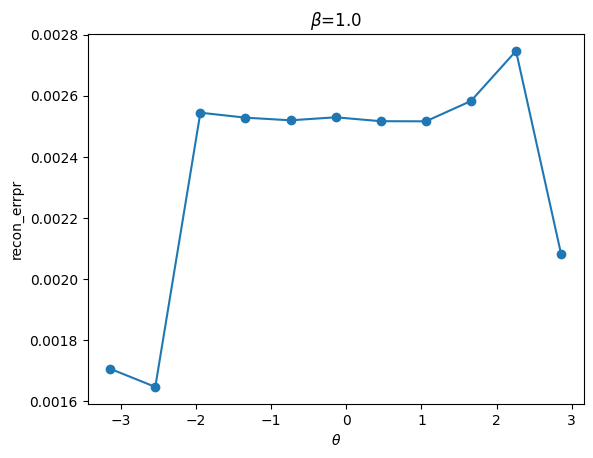

In [19]:
plt.plot(df['theta'], df['recon_error'])
plt.scatter(df['theta'], df['recon_error'])
plt.xlabel(r'$\theta$')
plt.ylabel('recon_errpr')
plt.title(r'$\beta$='+str(beta))
plt.savefig("{}/recon_error.png".format(dirname_res))
plt.show()

#### Physical quantities calculated by the generated sampling

In [20]:
def quantities_fromGeneratedSampling(df, encoder, decoder, params, key):
    df = recon_xs(df, encoder, decoder, params, key)
    quantity_fromSample(df, 'samples_recon', "Szs", 'recon')
    quantity_fromSample(df, 'samples_recon', "stgcor", "recon")
    return df

def plot_quantities_fromGeneratedSampling(df, df_train, df_test, dirname_res):
    pass

In [21]:
df = quantities_fromGeneratedSampling(df, encoder, decoder, params, key)
df.head()

/tmp/ipykernel_14846/2115445960.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  cor[j-2] += -1.0*samples[s,0]*cmath.exp(1j*pi*samples[s, 1:j-1].sum())*samples[s, j-1]


,theta,samples,Szs_true,stgcor_true,samples_recon,recon_error,Szs_recon,stgcor_recon
0,-3.142,"[[1, 0, 0, 1, 1, 1, 0, 0, 1, 0, -1, 1, 0, 0, 1...","[0.334, 0.26, 0.33, 0.344, 0.378, 0.334, 0.362...","[-0.082, 0.028, 0.022, -0.024, -0.012, 0.0, -0...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.001706,"[0.342, 0.208, 0.188, 0.272, 0.228, 0.252, 0.2...","[0.018, 0.008, -0.022, -0.026, 0.006, -0.006, ..."
1,-2.542,"[[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, -1, -...","[0.364, 0.434, 0.382, 0.418, 0.36, 0.38, 0.398...","[-0.13, 0.06, 0.0, -0.014, -0.02, 0.014, -0.06...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.001647,"[0.342, 0.208, 0.188, 0.272, 0.228, 0.252, 0.2...","[0.018, 0.008, -0.022, -0.026, 0.006, -0.006, ..."
2,-1.942,"[[0, 0, 0, 0, 1, -1, 1, -1, -1, 1, 1, -1, 1, -...","[-0.05, 0.032, 0.046, -0.024, -0.01, 0.012, 0....","[0.584, 0.084, 0.096, 0.008, 0.04, -0.014, 0.0...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.002544,"[0.342, 0.208, 0.188, 0.272, 0.228, 0.252, 0.2...","[0.018, 0.008, -0.022, -0.026, 0.006, -0.006, ..."
3,-1.342,"[[1, -1, -1, 1, -1, 1, 1, -1, 1, -1, 1, -1, 0,...","[0.092, -0.092, 0.048, -0.072, -0.004, 0.032, ...","[0.602, 0.126, 0.16, 0.04, 0.058, 0.026, 0.042...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.002528,"[0.342, 0.208, 0.188, 0.272, 0.228, 0.252, 0.2...","[0.018, 0.008, -0.022, -0.026, 0.006, -0.006, ..."
4,-0.742,"[[1, -1, 0, -1, 0, 1, 0, 0, -1, 1, 0, 0, 0, 0,...","[-0.012, -0.028, 0.082, -0.072, -0.004, 0.05, ...","[0.612, 0.248, 0.246, 0.116, 0.124, 0.114, 0.1...","[[0.0, 1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0...",0.002520,"[0.342, 0.208, 0.188, 0.272, 0.228, 0.252, 0.2...","[0.018, 0.008, -0.022, -0.026, 0.006, -0.006, ..."


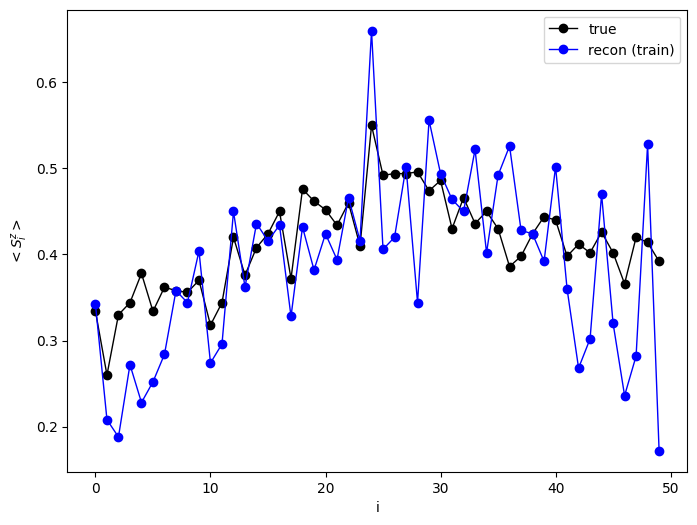

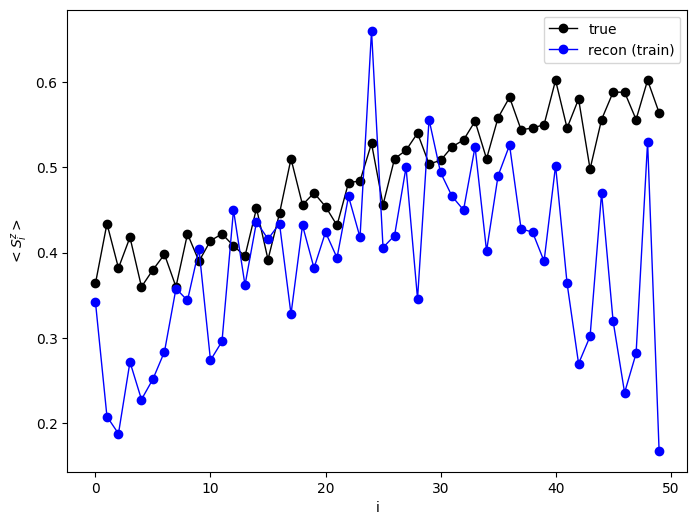

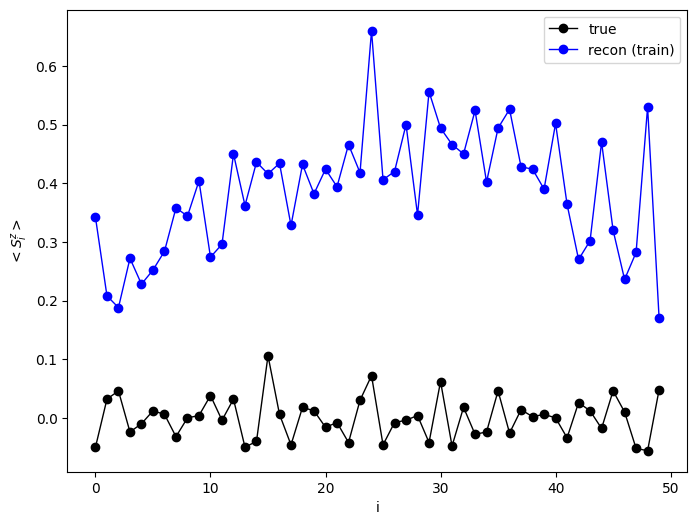

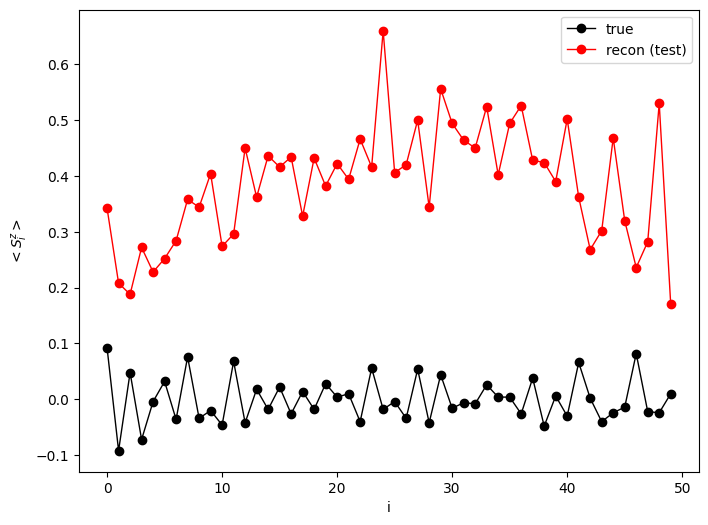

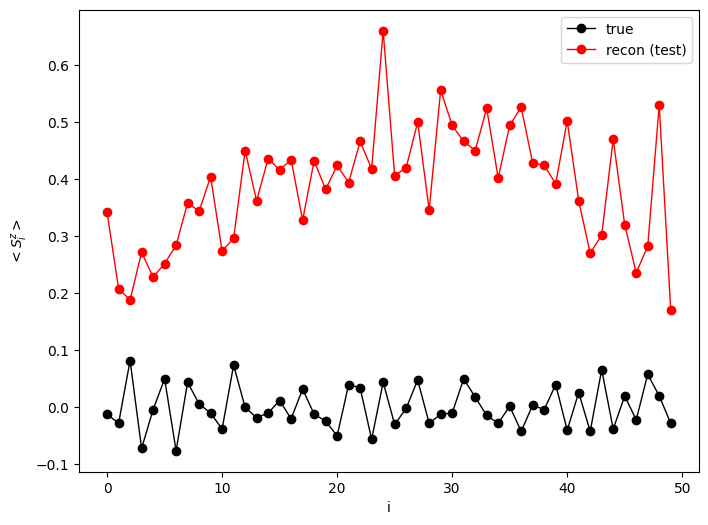

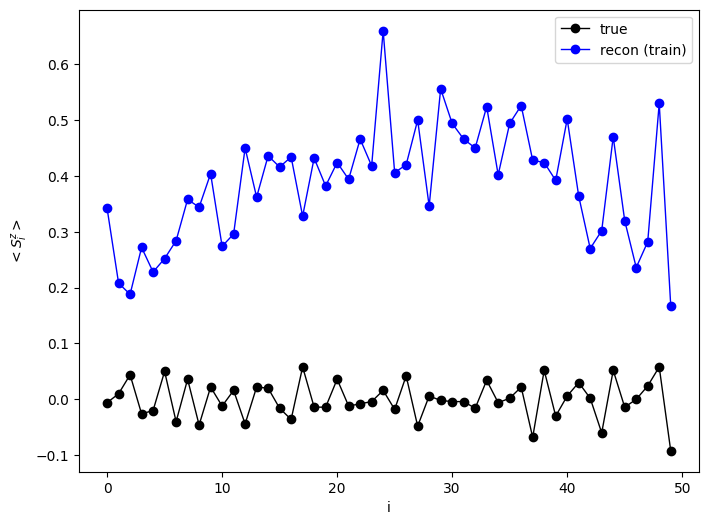

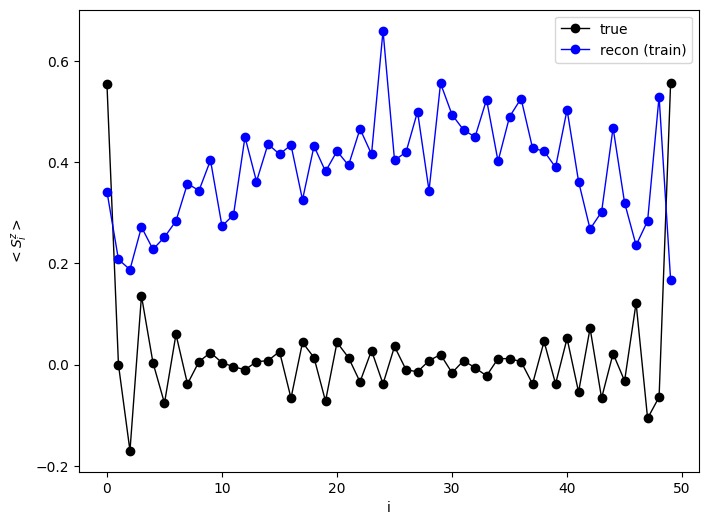

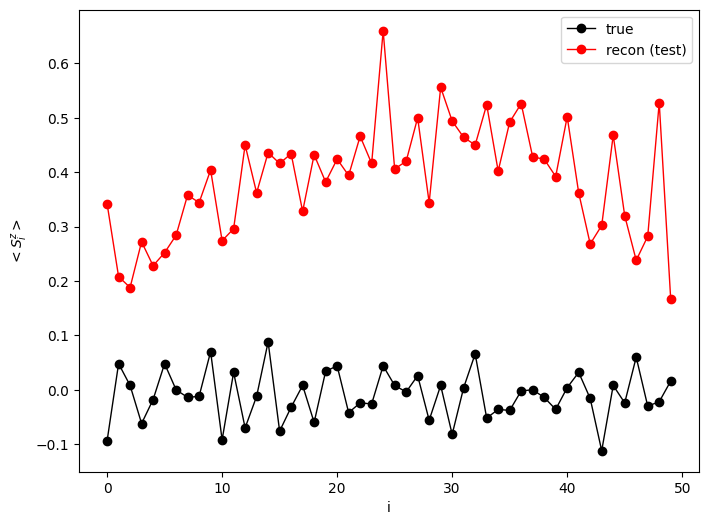

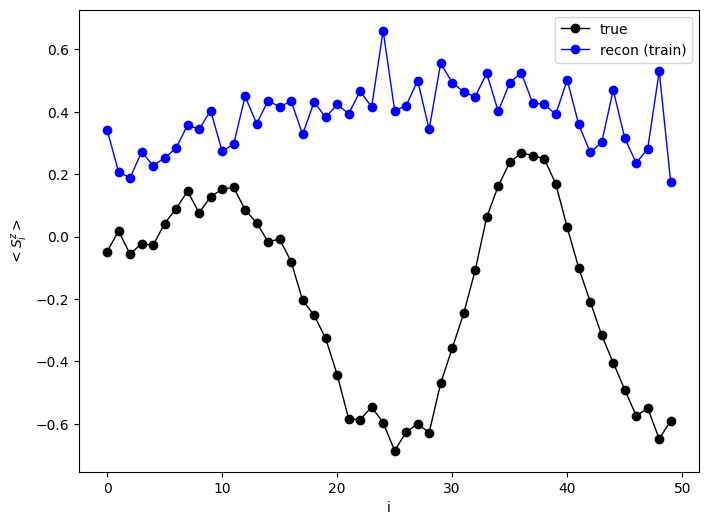

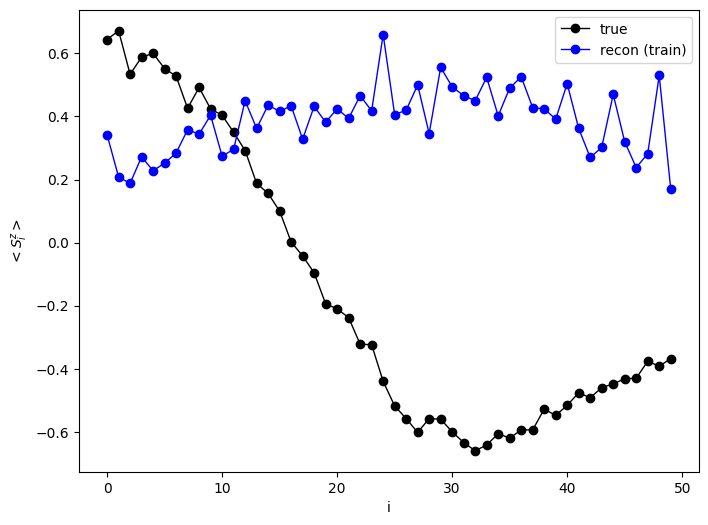

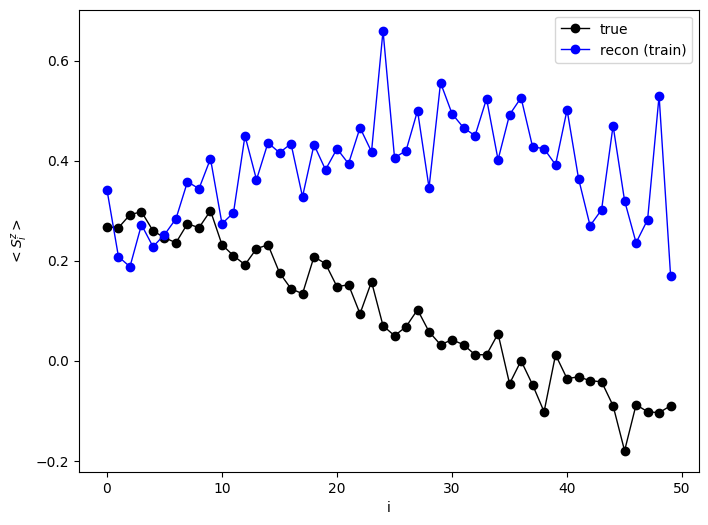

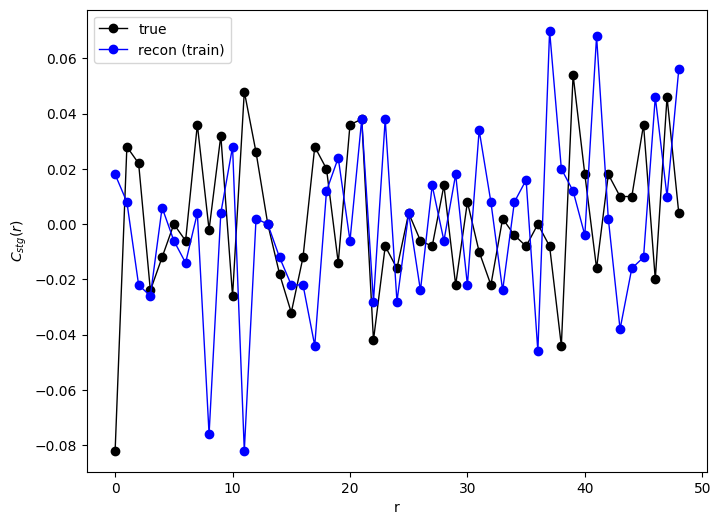

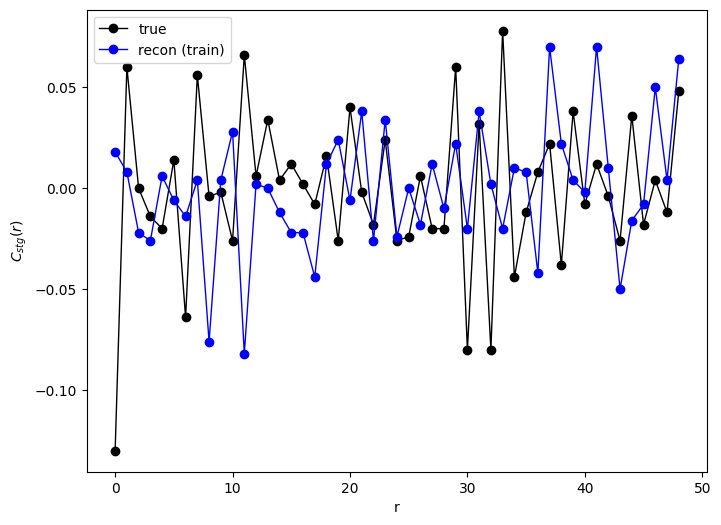

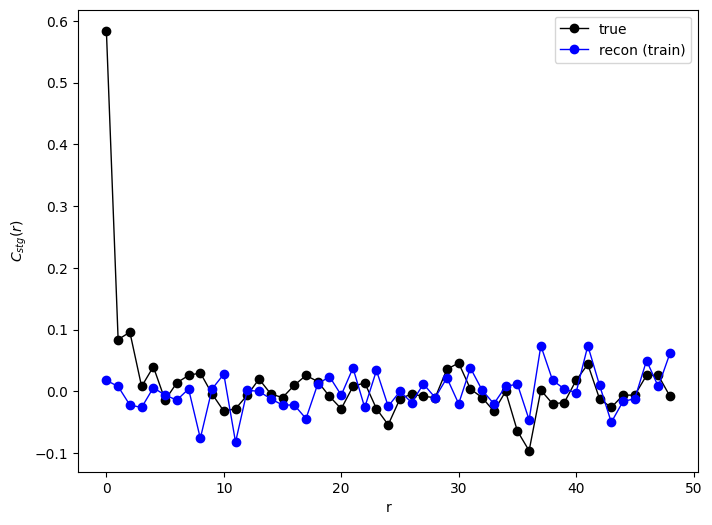

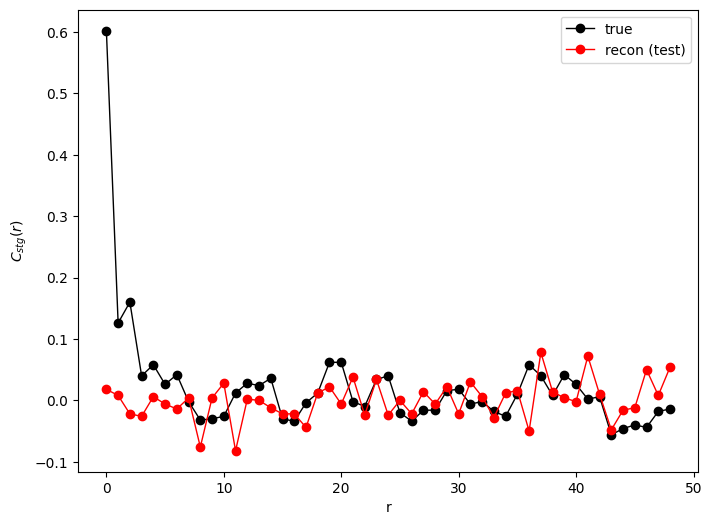

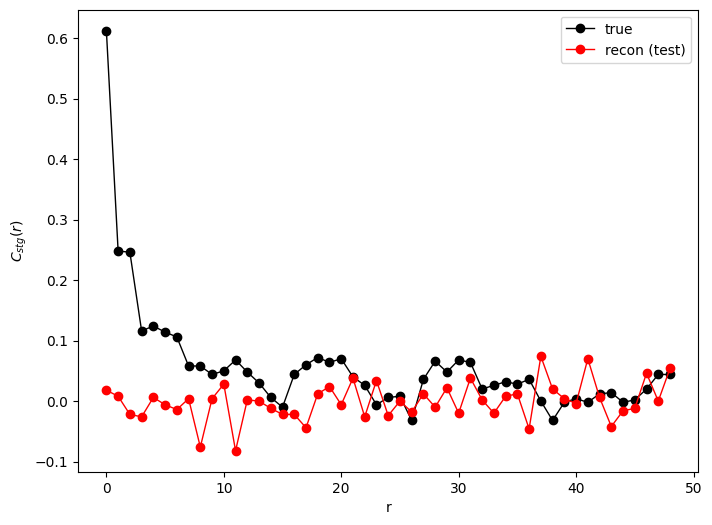

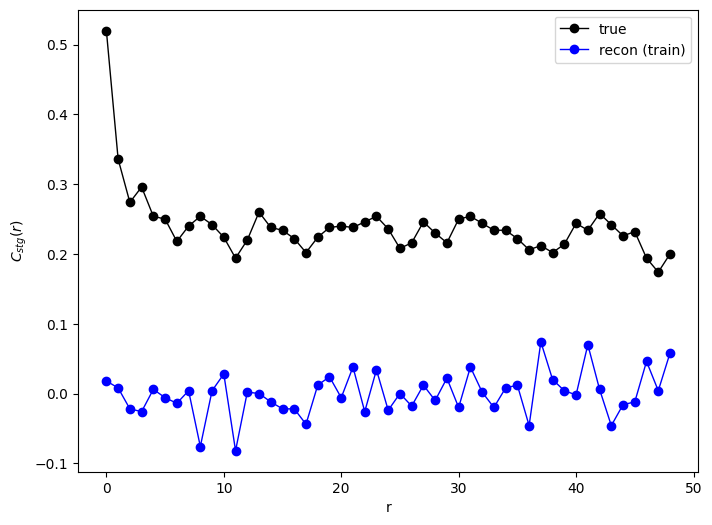

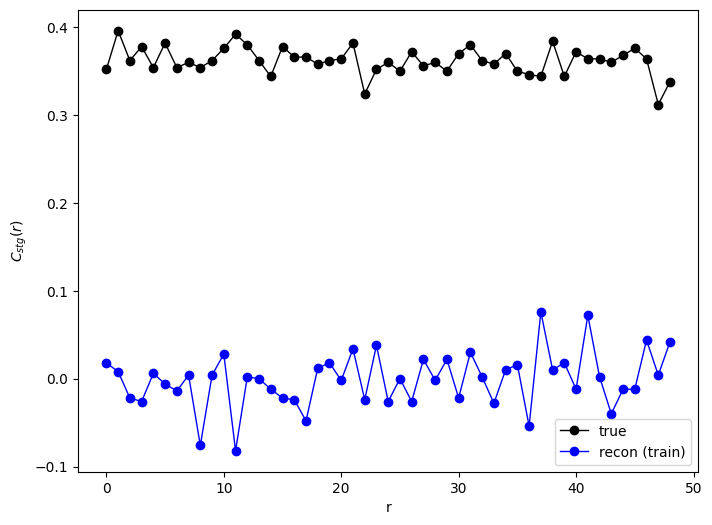

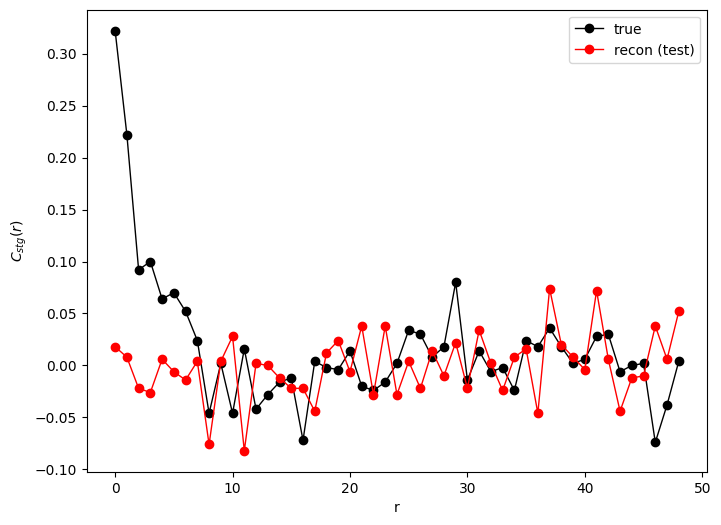

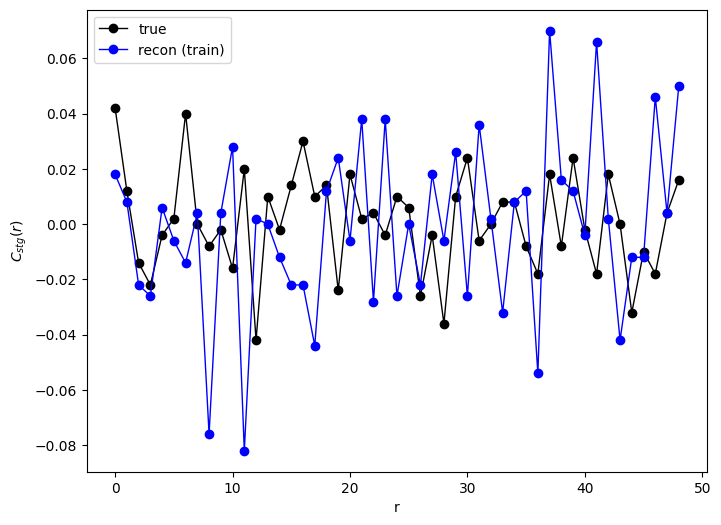

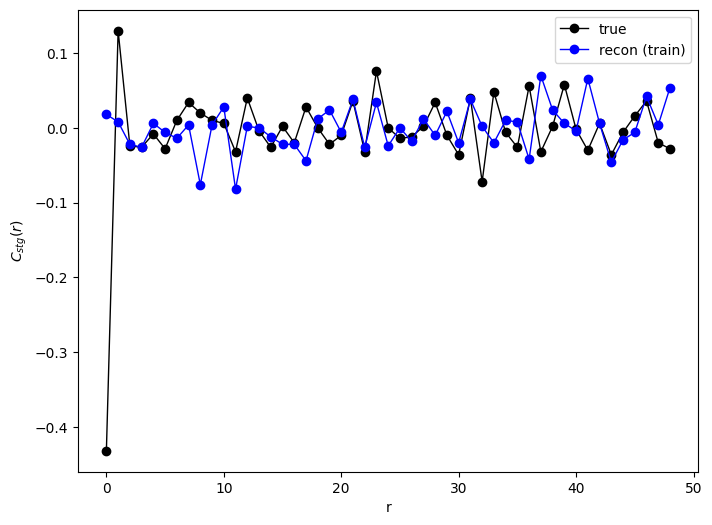

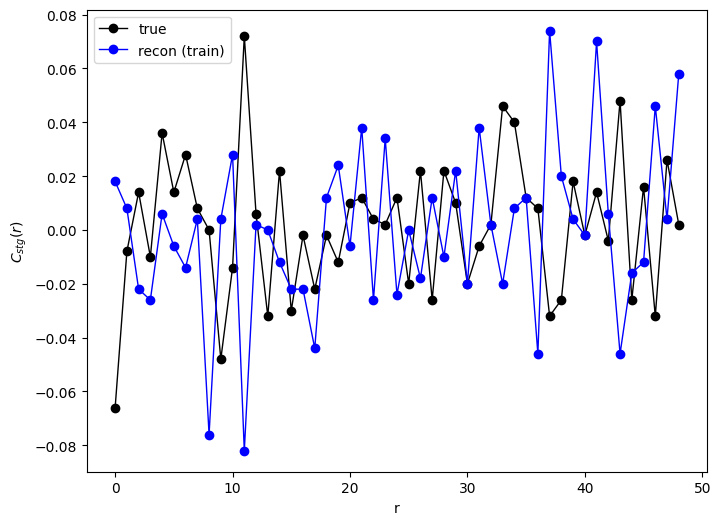

In [22]:
dirname_plot = dirname_res+"/reconsructed_quantities"
os.makedirs(dirname_plot, exist_ok=True)

train_index = df_train.index.tolist()
test_index = df_test.index.tolist()
# Szs
for i in df.index.tolist():
    plt.figure(figsize=(8,6))
    plt.xlabel('i')
    plt.ylabel('$<S_i^z>$')
    plt.plot(df.loc[i]['Szs_true'], label='true', color='black', marker='o', lw=1)
    if i in train_index:
        plt.plot(df.iloc[i]['Szs_recon'], label='recon (train)', color='blue', marker='o', lw=1)
    elif i in test_index:
        plt.plot(df.iloc[i]['Szs_recon'], label='recon (test)', color='red', marker='o', lw=1)
    else:
        pass 
    plt.legend()
    plt.savefig("{}/Sz_theta{}.png".format(dirname_plot, str(df.loc[i]['theta'])))
    plt.show()
    plt.close()

# sdtgcor
for i in df.index.tolist():
    plt.figure(figsize=(8,6))
    plt.xlabel('r')
    plt.ylabel('$C_{stg}(r)$')
    plt.plot(df.loc[i]['stgcor_true'], label='true', color='black', marker='o', lw=1)
    if i in train_index:
        plt.plot(df.iloc[i]['stgcor_recon'], label='recon (train)', color='blue', marker='o', lw=1)
    elif i in test_index:
        plt.plot(df.iloc[i]['stgcor_recon'], label='recon (test)', color='red', marker='o', lw=1)
    else:
        pass 
    plt.legend()
    plt.savefig("{}/stgcor_theta{}.png".format(dirname_plot, str(df.loc[i]['theta'])))
    plt.show()
    plt.close()


#### latent space

In [23]:
def meanval(df, encoder, params, key):
    params_encoder = params[0]
    meanvals = []
    for i in range(len(df)):
        x = jnp.array(df.iloc[i]['samples']) # (number of samples)*N
        meanval, _, _ = encoder.apply({'params': params_encoder}, x, key)
        meanvals.append(jnp.mean(meanval, axis=0).tolist())
    for i in range(len(meanvals[0])):
        df['$\mu_{}$'.format(i)] = [row[i] for row in meanvals]
    return df
def plot_meanval(df, latent_dim, dirname_res):
    for i in range(latent_dim):
        plt.plot(df['$\mu_{}$'.format(i)], label='$\mu_{}$'.format(i))
    plt.xlabel('$\Theta$')
    plt.ylabel('$\mu$')
    plt.legend()
    plt.savefig("{}/meanval.png".format(dirname_res))
    plt.show()
    

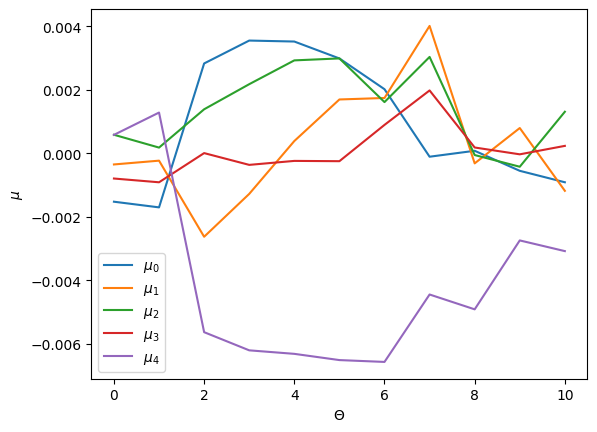

In [24]:
df = meanval(df, encoder, params, key)
plot_meanval(df, latent_dim, dirname_res)

In [25]:
filename = '{}/'.format(dirname_res) + "latdim_{}".format(latent_dim) + "_beta_{}".format(beta) + "_df.csv"
df.to_csv(filename, index=False, encoding='utf-8-sig')

#### latent scan

In [ ]:
mu_num  = 100  # # of data points in latent space
dfs = []
for lat_num in range(latent_dim):
    print('latent number: {}'.format(lat_num))
    # get minimum and maximum value of mu in one latent space
    # plt.hist() will return (array of # of data) and (array of values)
    mu_hist = plt.hist(df['$\\mu_{}$'.format(lat_num)])[1]
    mus = jnp.linspace(mu_hist[0],mu_hist[-1],mu_num)
    
    # container for samples (# of data points of mu)*(# of samples)*(system size)
    all_samples = jnp.zeros((len(mus), Nsamples, N))
    all_Szs = []
    Szs_mean = []
    all_stgcor = []
    stgop = []
    for i, mu in enumerate(mus):
        # set only one dimension in latent space has a specific value
        m = mus[j]*jnp.ones((Nsamples,))
        z = jnp.zeros((Nsamples, latent_dim)) # initialization
        z = z.at[:, lat_num].set(m) # set 'mu' to only specific dimension (lat_num)
    
        # generate samples from specific latent value 'z'
        key,_ = jax.random.split(key)
        recon_x = get_sample(decoder, params_decoder, z, key)
        all_samples = all_samples.at[i,:].set(recon_x)
        
        # physical quantities
        # S^z_i
        # take average over the number of sample
        Szs = Sz_fromSamples(recon_x)
        all_Szs.append(Szs)
        # average over all the lattice sites
        Szs_mean.append(np.array(Szs).mean().item())
        # stgcor
        stgcor = stgcor_fromSamples(recon_x.tolist())
        all_stgcor.append(stgcor)
        stgop.append(stgcor[-1])
    d = {
        'mu': mus,
        'all_Szs' : all_Szs,
        'all_Szs_mean': Szs_mean,
        'all_stgcor': all_stgcor,
        'all_stgop': stgop
    }
    dfs.append(pd.DataFrame(d))



latent number: 0


/tmp/ipykernel_14846/2115445960.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  cor[j-2] += -1.0*samples[s,0]*cmath.exp(1j*pi*samples[s, 1:j-1].sum())*samples[s, j-1]


In [ ]:
# plot
for i,d in enumerate(dfs):
    plt.ylim(-1,1)
    plt.scatter(d['mu'], d['all_Szs_mean'], label='$(1/N)\sum_iS^z_i$')
    plt.xlabel('z')    
    plt.ylabel('mean $S^z$')
    plt.legend()
    plt.savefig("{}/latent_No_{}_meanSz.png".format(dirname_res, i))
    plt.show()
    plt.clf()

for i,d in enumerate(dfs):
    plt.ylim(-1,1)
    plt.scatter(d['mu'], d['all_stgop'], label='$O=C(r=r_{max})$')
    plt.xlabel('z')    
    plt.ylabel('$O_{stg}$')
    plt.legend()
    plt.savefig("{}/latent_No_{}_Ostg.png".format(dirname_res, i))
    plt.show()
    plt.clf()

In [ ]:
# output
for i,d in enumerate(dfs):
    filename = '{}/'.format(dirname_res) + "latent_No_{}".format(i) + ".csv"
    d.to_csv(filename, index=False, encoding='utf-8-sig')